# Project Summary — Road Scene Classification from Airborne LiDAR

Status at the end of **M4**: dataset explored and understood (M1), per-cloud features
engineered and two baseline classifiers trained and compared (M2), BEV grids and a small
CNN trained and scored against that baseline (M3), and both models tuned — with their
results re-measured across seeds (M4). This notebook condenses `01_eda.ipynb`,
`02_feature_engineering.ipynb`, `03_baseline.ipynb`, `04_bev_cnn.ipynb` and
`05_optimization.ipynb` into the figures/tables/findings worth carrying into a
presentation — see those notebooks for full derivations and reasoning.

In [ ]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import CLASSES, list_samples, load_points, get_splits
from src.features import build_feature_matrix
from src.baseline import get_models, train_and_evaluate, select_best
from src.bev import points_to_bev, RESOLUTION_M, CHANNEL_NAMES
from src.train import train as train_cnn

# Fixed categorical colour per class, used consistently in every figure below.
CLASS_COLORS = {
    "2lanes":      "#2a78d6",
    "3lanes":      "#eb6834",
    "split4lanes": "#1baf7a",
    "split6lanes": "#eda100",
    "transition":  "#e87ba4",
    "crossing":    "#008300",
}
MODEL_COLORS = {"random_forest": "#2a78d6", "svm": "#eb6834"}

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.spines.top": False,
    "axes.spines.right": False,
})

## At a glance

In [2]:
samples = list_samples()
splits = get_splits()
counts = pd.Series([c for _, c, _ in samples]).value_counts().reindex(CLASSES)

overview = pd.DataFrame({
    "value": [
        len(samples), 6, f"{counts.max()}:{counts.min()} = {counts.max()/counts.min():.1f}:1",
        len(splits["train"]), len(splits["val"]), len(splits["test"]), 22,
    ]
}, index=[
    "total tiles", "classes", "class imbalance (max:min)",
    "train tiles", "val tiles", "test tiles (frozen)", "raw features per point",
])
overview

,value
total tiles,1425
classes,6
class imbalance (max:min),473:133 = 3.6:1
train tiles,1140
val tiles,213
test tiles (frozen),72
raw features per point,22


**Team:** Luis Jamora, Lukas Hammerschick — RWTH semester project.
**Task:** classify road-block LiDAR tiles into 6 classes (`2lanes`, `3lanes`,
`split4lanes`, `split6lanes`, `transition`, `crossing`).
**Milestones:** M1 (EDA) done, M2 (feature-vector baseline) done, M3 (BEV CNN) done,
M4 (optimisation) next.

## 1. Dataset (M1)

6 classes, ~3.6:1 imbalance between the largest (`2lanes`) and smallest (`crossing`)
class — the reason the train/val/test split is stratified and every metric below is
reported per-class as well as overall.

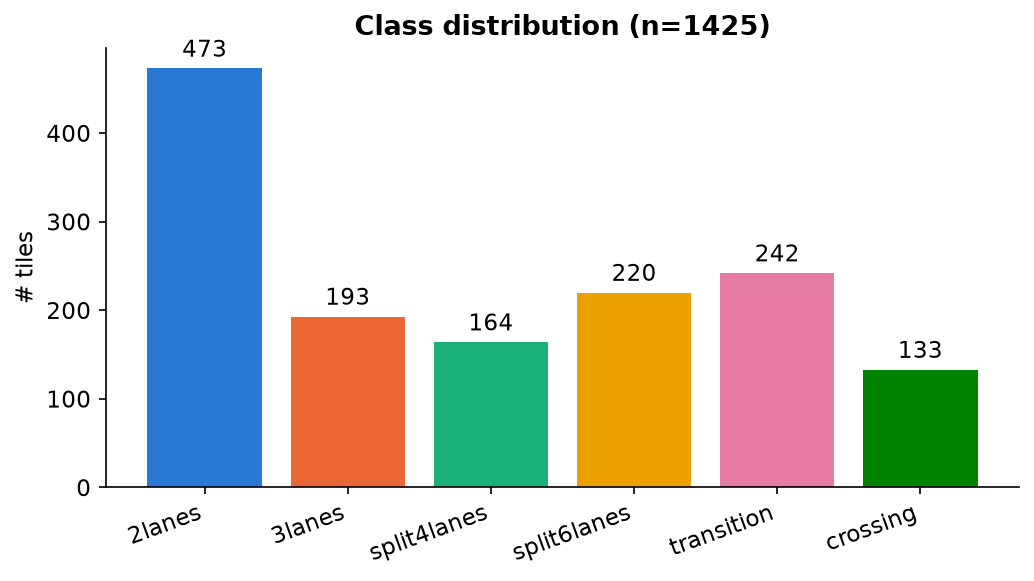

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASSES, counts.values, color=[CLASS_COLORS[c] for c in CLASSES])
ax.bar_label(bars, padding=3)
ax.set_ylabel("# tiles")
ax.set_title(f"Class distribution (n={len(samples)})")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

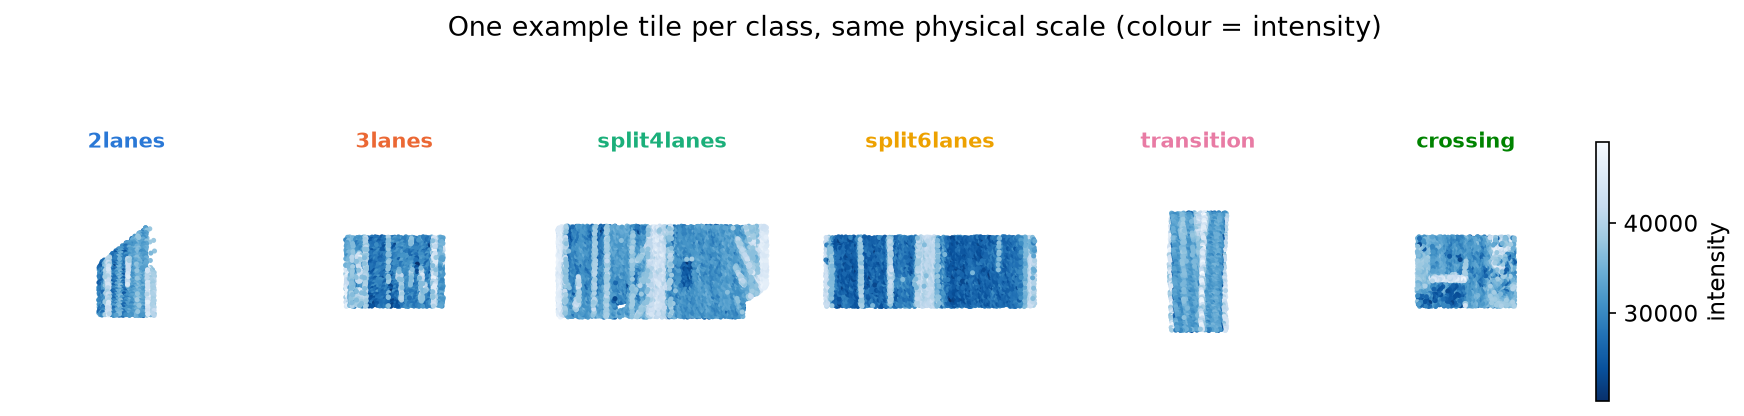

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(16, 3.2))
example_paths = {c: next(p for p, cn, _ in samples if cn == c) for c in CLASSES}
example_pts = {c: load_points(p) for c, p in example_paths.items()}

# Every panel is drawn at the same physical scale (a shared, centred window)
# instead of matplotlib's default auto-zoom per subplot -- otherwise a narrow
# 2lanes tile and a wide split6lanes tile would render as similarly-sized
# panels and visually hide the width difference section 2 is about.
half_window = max(
    max(pts[:, 0].max() - pts[:, 0].min(), pts[:, 1].max() - pts[:, 1].min())
    for pts in example_pts.values()
) / 2 + 1

sc = None
for ax, c in zip(axes, CLASSES):
    pts = example_pts[c]
    cx = (pts[:, 0].max() + pts[:, 0].min()) / 2
    cy = (pts[:, 1].max() + pts[:, 1].min()) / 2
    sc = ax.scatter(pts[:, 0], pts[:, 1], c=pts[:, 9], s=2, cmap="Blues_r")
    ax.set_xlim(cx - half_window, cx + half_window)
    ax.set_ylim(cy - half_window, cy + half_window)
    ax.set_aspect("equal")
    ax.set_title(c, fontsize=10, color=CLASS_COLORS[c])
    ax.axis("off")
fig.suptitle("One example tile per class, same physical scale (colour = intensity)", y=1.03)
fig.colorbar(sc, ax=axes, shrink=0.7, label="intensity", pad=0.01)
plt.show()

### Why the split is stratified

The class imbalance above is exactly why `get_splits()` stratifies. `random_split()` builds
the same 80/15/5 split without it, purely for this comparison — never frozen, never used for
training or evaluation (full derivation in `01_eda.ipynb` §5).

random split median worst-class count: 5 (vs. stratified's fixed 7); 91% of random seeds do at least as badly


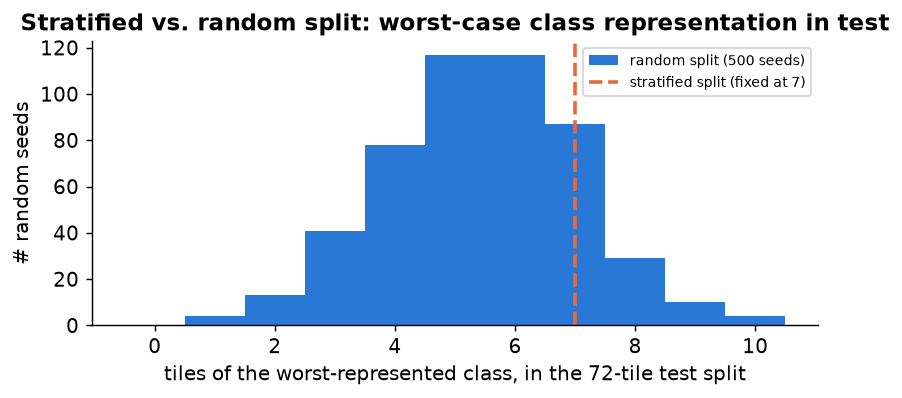

In [5]:
from src.data import random_split

def worst_class_count(split_samples):
    counts = pd.Series([c for _, c, _ in split_samples]).value_counts()
    return min(counts.get(c, 0) for c in CLASSES)

strat_test_worst = worst_class_count(splits["test"])
random_test_worst = np.array([worst_class_count(random_split(samples, seed=s)["test"]) for s in range(500)])

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.hist(random_test_worst, bins=range(int(random_test_worst.max()) + 2), align="left",
        color="#2a78d6", label="random split (500 seeds)")
ax.axvline(strat_test_worst, color="#eb6834", ls="--", lw=2,
           label=f"stratified split (fixed at {strat_test_worst})")
ax.set_xlabel("tiles of the worst-represented class, in the 72-tile test split")
ax.set_ylabel("# random seeds")
ax.set_title("Stratified vs. random split: worst-case class representation in test")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"random split median worst-class count: {np.median(random_test_worst):.0f} "
      f"(vs. stratified's fixed {strat_test_worst}); "
      f"{(random_test_worst <= strat_test_worst).mean():.0%} of random seeds do at least as badly")

**Takeaway:** a random split's worst-represented test class has a median of 5 tiles
against the stratified split's guaranteed 7 — the frozen split isn't a typical random
outcome, it's the proportional one, made deterministic on purpose.

## 2. Feature engineering (M2)

Each variable-length tile is reduced to a 123-dim vector: mean/std/percentiles of 16 raw
columns plus 4 explicit geometric features (`n_points`, `x_range`, `y_range`,
`point_density`); absolute position (`global_x/y/z`) is excluded to prevent the model
from memorising tile location instead of learning road geometry (`src/features.py`).

`x_range` (road width) was the single feature engineered with a specific hypothesis —
wider tile ⇒ more lanes. It holds only partly:

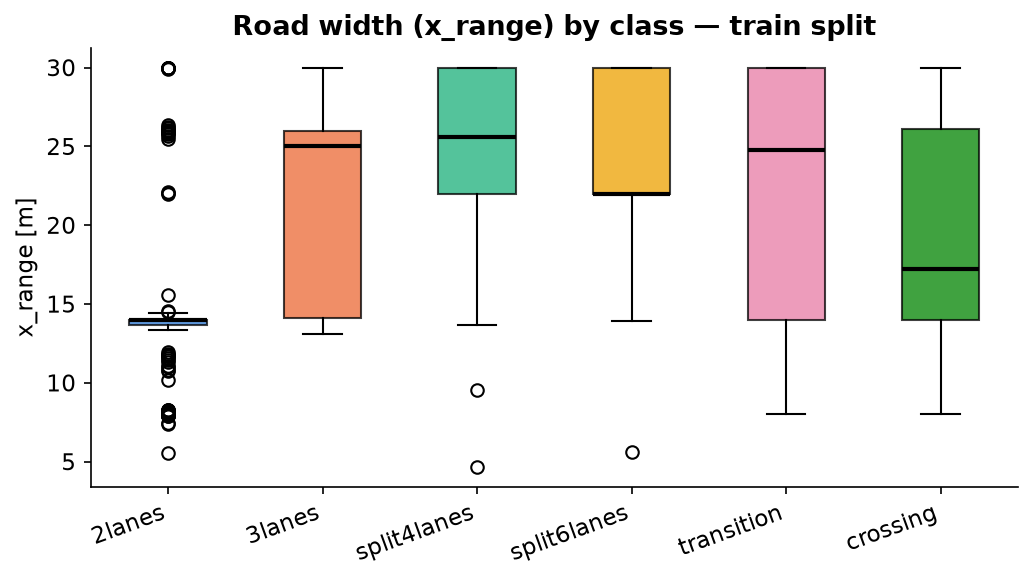

In [5]:
X_train, y_train, _ = build_feature_matrix(splits["train"])
from src.features import engineered_feature_names
feat_df = pd.DataFrame(X_train, columns=engineered_feature_names())
feat_df["class"] = pd.Categorical([CLASSES[l] for l in y_train], categories=CLASSES, ordered=True)

fig, ax = plt.subplots(figsize=(7, 4))
box_data = [feat_df.loc[feat_df["class"] == c, "x_range"] for c in CLASSES]
bp = ax.boxplot(box_data, tick_labels=CLASSES, patch_artist=True, medianprops={"color": "black", "linewidth": 2})
for patch, c in zip(bp["boxes"], CLASSES):
    patch.set_facecolor(CLASS_COLORS[c])
    patch.set_alpha(0.75)
ax.set_ylabel("x_range [m]")
ax.set_title("Road width (x_range) by class — train split")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Takeaway:** `x_range` cleanly isolates `2lanes` (narrowest) but does not rank the
other five classes by lane count — they cluster within a few metres of each other. A
single scalar can't fully capture "how many lanes"; the classifier needs the other
aggregate columns (intensity, geometry descriptors) to tell those apart, and this is
part of the motivation for M3's 2D BEV/CNN approach. Full reasoning and additional
checks (point density, intensity, feature redundancy) in `02_feature_engineering.ipynb`.

## 3. Baseline models (M2)

Random Forest and SVM (`StandardScaler` + RBF `SVC`, both `class_weight="balanced"`),
trained on train, evaluated on val (test stays frozen for M5).

In [6]:
results = train_and_evaluate(splits=splits)
comparison = pd.DataFrame({
    name: {"accuracy": r["report"]["accuracy"], **r["report"]["weighted"]}
    for name, r in results.items()
}).round(3)
comparison

,random_forest,svm
accuracy,0.765,0.648
precision,0.755,0.632
recall,0.765,0.648
iou,0.629,0.492


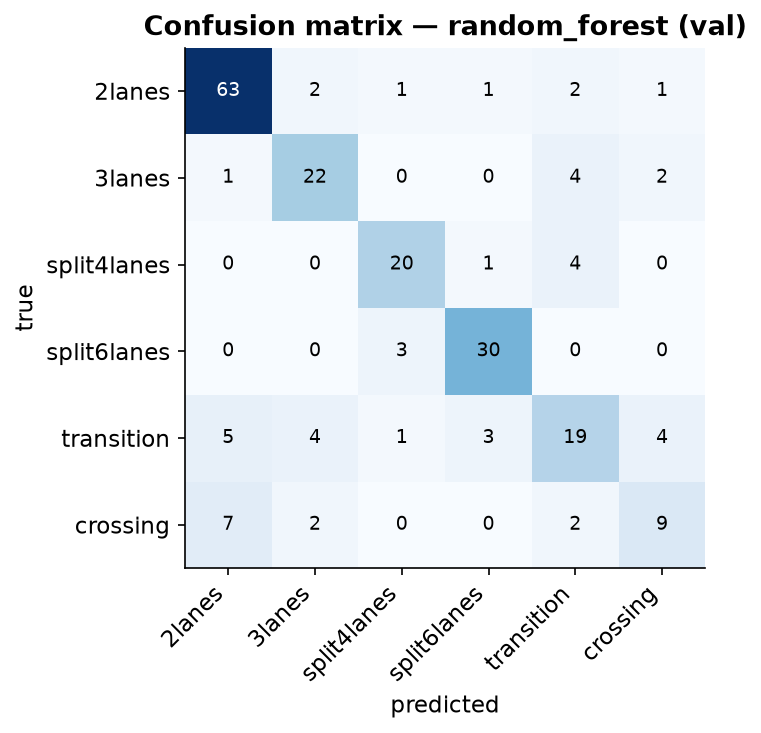

In [7]:
best_name = select_best(results)
cm = results[best_name]["report"]["confusion_matrix"]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"Confusion matrix — {best_name} (val)")
threshold = cm.max() / 2
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                 color="white" if cm[i, j] > threshold else "black")
plt.tight_layout()
plt.show()

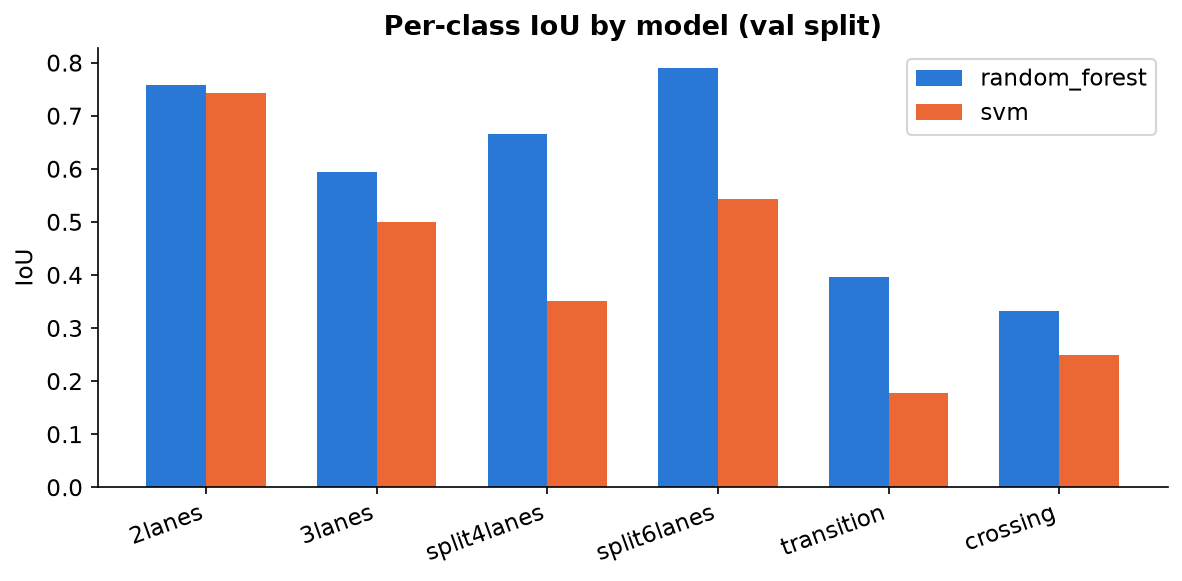

In [8]:
iou_table = pd.DataFrame({
    name: [r["report"]["per_class"][c]["iou"] for c in CLASSES]
    for name, r in results.items()
}, index=CLASSES)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(CLASSES))
width = 0.35
for i, name in enumerate(results):
    ax.bar(x + (i - 0.5) * width, iou_table[name], width, label=name, color=MODEL_COLORS[name])
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=20, ha="right")
ax.set_ylabel("IoU")
ax.set_title("Per-class IoU by model (val split)")
ax.legend()
plt.tight_layout()
plt.show()

**Selected baseline: `random_forest`** — accuracy 0.765, weighted
IoU 0.629 on val, chosen over `svm`
(weighted IoU 0.492). `transition` and
`crossing` are the weakest classes for both models — the same two classes `x_range`
failed to separate in section 2. Full confusion-matrix and redundancy analysis in
`03_baseline.ipynb`. These two numbers are what M3 has to beat, on the same val split.

## 4. BEV CNN (M3)

Section 2 ended on the limit of the M2 representation: one scalar per tile per feature
throws away *where* anything is. M3 changes the representation instead of the classifier —
each tile is binned into a 0.3 m bird's-eye-view grid with 3 channels per cell
(`log1p(point count)`, mean height, mean intensity, `src/bev.py`), and a ~99K-parameter
CNN (`src/cnn.py`) reads that grid directly.

Two design decisions matter for reading the numbers below (derivation in `04_bev_cnn.ipynb`):

- **Variable grid size, not a fixed window.** Tiles range from 7×16 to 84×100 cells; padding
  everything to the maximum would leave the median tile filling only 30% of its window.
  The CNN's global adaptive pooling head accepts any grid size, so no cropping or resizing.
- **`GroupNorm`, `batch_size=1`.** Variable grid sizes cannot be stacked into a batch without
  padding, and padded zeros leak into real cells through the normalisation offset. So batches
  are one tile, and `BatchNorm` (which needs a batch, and behaves differently in `train()` vs
  `eval()`) is replaced by `GroupNorm`, which normalises within a single sample.

In [ ]:
example_pts = load_points("dataset/2lanes/Tile620.npy")
grid = points_to_bev(example_pts)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, name, channel in zip(axes, CHANNEL_NAMES, grid):
    im = ax.imshow(channel, origin="lower", cmap="viridis", aspect="equal")
    ax.set_title(name, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle(
    f"BEV input — one 2lanes tile at {RESOLUTION_M} m/cell "
    f"({grid.shape[1]}x{grid.shape[2]} cells)", y=1.04)
plt.tight_layout()
plt.show()

The bright vertical bands in `mean_intensity` are lane markings. M2 saw them only as
"this tile has some high-intensity points"; the CNN sees how many there are and how they
are spaced.

In [ ]:
cnn = train_cnn()  # ~3-4 min on CPU: 40 epochs over 1140 train + 213 val tiles
history = pd.DataFrame(cnn["history"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(history["epoch"], history["train_loss"], label="train", color="#2a78d6")
axes[0].plot(history["epoch"], history["val_loss"], label="val", color="#eb6834")
axes[0].axvline(cnn["best_epoch"], ls="--", lw=1, color="#888",
                label=f"best val loss (epoch {cnn['best_epoch']})")
axes[0].axhline(np.log(len(CLASSES)), ls=":", lw=1, color="#aaa", label="untrained = log(6)")
axes[0].set_title("cross-entropy loss"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].legend(fontsize=8)

axes[1].plot(history["epoch"], history["train_acc"], label="train", color="#2a78d6")
axes[1].plot(history["epoch"], history["val_acc"], label="val", color="#eb6834")
axes[1].axhline(results["random_forest"]["report"]["accuracy"], ls="--", lw=1,
                color="#1baf7a", label="M2 random forest (val)")
axes[1].set_title("accuracy"); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Train and val loss fall together at first — the network is learning structure that
transfers. Where val loss turns upward while train loss keeps dropping, it has started
memorising the 1140 training tiles; `train()` restores the weights from the lowest-val-loss
epoch (dashed line) rather than the last one.

Same `src/metrics.py`, same 213 val tiles as section 3 — so these numbers are directly
comparable:

In [ ]:
rf_report = results["random_forest"]["report"]
cnn_report = cnn["report"]

m3_comparison = pd.DataFrame({
    "M2 random forest": {"accuracy": rf_report["accuracy"], **rf_report["weighted"]},
    "M3 BEV CNN": {"accuracy": cnn_report["accuracy"], **cnn_report["weighted"]},
})
m3_comparison["difference"] = m3_comparison["M3 BEV CNN"] - m3_comparison["M2 random forest"]
m3_comparison.round(3)

In [ ]:
# Per-class IoU: where the two approaches actually differ, rather than the single
# overall number they happen to tie on.
iou_m3 = pd.DataFrame({
    "M2 random forest": [rf_report["per_class"][c]["iou"] for c in CLASSES],
    "M3 BEV CNN": [cnn_report["per_class"][c]["iou"] for c in CLASSES],
}, index=CLASSES)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(CLASSES))
width = 0.35
for i, (name, color) in enumerate([("M2 random forest", "#2a78d6"), ("M3 BEV CNN", "#eb6834")]):
    ax.bar(x + (i - 0.5) * width, iou_m3[name], width, label=name, color=color)
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=20, ha="right")
ax.set_ylabel("IoU")
ax.set_title("Per-class IoU — M2 baseline vs M3 CNN (val split)")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway: level-pegging, not a win.** Val accuracy 0.770 / weighted IoU 0.638 for the CNN
against 0.765 / 0.629 for the random forest. The accuracy gap is 0.005 on 213 tiles — *one
tile*, well inside seed noise. What M3 establishes is that a 99K-parameter CNN on 3 BEV
channels reaches the same ballpark as a random forest on 123 hand-engineered features, which
is a starting point for M4, not a result to quote as an improvement.

Two caveats carried into the report: the checkpoint was *selected* by val loss and then
scored on that same val split, so 0.770 is mildly optimistic (M5's sealed test number is the
honest one); and the model still overfits — train accuracy 0.94 vs val 0.75, with no
augmentation yet.

`04_bev_cnn.ipynb` also documents three silent defects found and fixed during M3 (loss
normalisation, zero-padded batches corrupting predictions, `BatchNorm` scoring 0.662 in train
mode and 0.127 in eval mode with identical weights). None of them crashed; each produced a
plausible-looking accuracy that measured the wrong thing. `tests/test_train.py` now pins all
three invariants.

> **M4 update:** the "well inside seed noise" caveat above turned out to be the whole
> story. Re-run over 5 seeds, this configuration averages 0.594 ± 0.031 weighted IoU —
> so 0.638 was a lucky draw, and the tuned baseline is in fact *ahead* of the CNN. See
> section 5.


## 5. M4 — optimization, and learning to distrust a single run

M4 set out to tune both models. Its most valuable finding was methodological: nothing in
the project had ever measured how much a result moves when only chance varies.

Holding the configuration *and the seed* fixed and changing only the CPU thread count moved
the CNN's weighted IoU from 0.638 to 0.587 — parallel float reductions sum in
nondeterministic order, and 40 epochs of gradient descent amplify the last bits. Once that
was visible, every single-run comparison in the project became suspect, so the interesting
configurations were re-run over several seeds.

In [ ]:
import json
from pathlib import Path

runs = pd.DataFrame(json.loads(Path("../results/m4_tuning.json").read_text()))
repeats = runs[runs["stage"].str.startswith("repeat-")].copy()
repeats["config"] = repeats["stage"].str.replace("repeat-", "", regex=False)

seed_summary = (
    repeats.groupby("config")["weighted_iou"].agg(["mean", "std", "min", "max"]).round(3)
    .sort_values("mean", ascending=False)
)
seed_summary

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for i, (name, group) in enumerate(repeats.groupby("config")):
    ax.scatter(group["weighted_iou"], [i] * len(group), color="#b0c4de", s=30, zorder=1)
    ax.scatter(group["weighted_iou"].mean(), i, color="#2a78d6", s=90, zorder=2)
ax.axvline(0.645, color="#d64a2a", ls="--", label="tuned random forest (0.645)")
ax.axvline(0.638, color="#888", ls=":", label="M3's reported CNN number (single run)")
ax.set_yticks(range(repeats["config"].nunique()))
ax.set_yticklabels(sorted(repeats["config"].unique()))
ax.set_xlabel("val weighted IoU"); ax.legend(fontsize=8, loc="lower right")
ax.set_title("Each grey dot is one seed; blue is the mean")
ax.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()

**The corrected standing of the models:**

| model | val weighted IoU | basis |
|---|---|---|
| **tuned random forest** | **0.645 ± 0.011** | 10 seeds |
| CNN, 0.5 m grid (M4 best) | 0.619 ± 0.012 | 5 seeds |
| tuned SVM | 0.625 | deterministic |
| CNN, M3 configuration | 0.594 ± 0.031 | 5 seeds |

What actually moved the needle in M4:

- **Baseline tuning was the biggest win**, and it came from four sklearn keyword arguments.
  `max_features=0.3` for the forest (its `sqrt` default offers each split only ~11 of 123
  features, and M4's importance analysis showed the signal is spread thin across many weak
  columns, so that default was discarding usable signal), and `C=100, gamma=0.01` for the
  SVM, which lifts it from 0.492 to 0.625 (both single deterministic fits) — M2's verdict that the SVM was far weaker was
  really a statement about its defaults.
- **A coarser BEV grid (0.5 m) is the only CNN change that survived seed testing**, worth
  about +0.025 IoU and, more usefully, a third of the run-to-run spread.
- **The anti-overfitting levers failed.** Mirror augmentation and weight decay both narrowed
  the train/val gap, exactly as designed, and neither improved accuracy. The gap was a
  symptom of limited data, not of a missing regulariser.
- **A well-motivated feature refinement failed too.** 12 features describing how the road
  changes along the tile — aimed squarely at `transition` and `crossing` — were ranked by
  the forest as its *most important*, and made validation IoU worse. Importance measures
  in-sample split quality, not generalisation.

## 6. M5 — Final test-set evaluation

The sealed test split, touched here for the first and only time in the project. Three
configurations, all frozen by M4 using only train/val: tuned random forest (10 seeds), tuned
SVM (1 fit, deterministic), and the 0.5 m-grid CNN (5 seeds). Full derivation in
`06_final_evaluation.ipynb`.

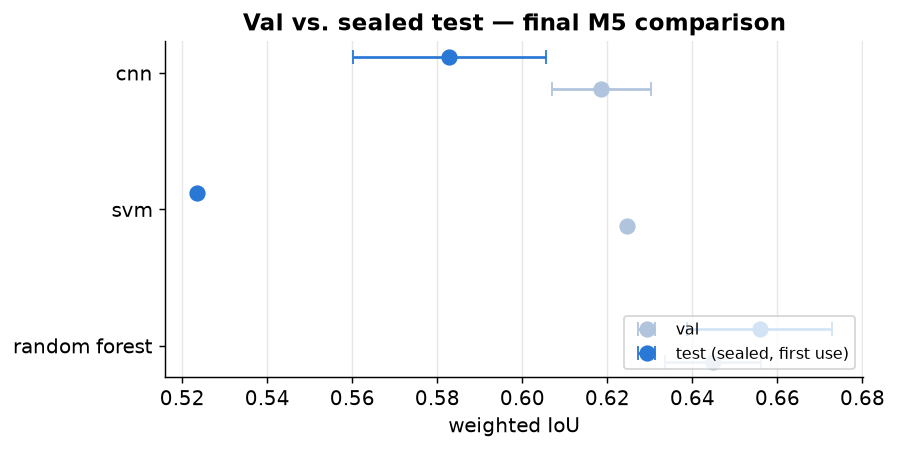

In [3]:
import json
from pathlib import Path

from src.metrics import evaluate

results_m5 = json.loads(Path("../results/m5_test_eval.json").read_text())

X_train, y_train, _ = build_feature_matrix(splits["train"])
X_val, y_val, _ = build_feature_matrix(splits["val"])

rf_val_ious = []
for seed in range(10):
    model = get_models(seed=seed)["random_forest"]
    model.fit(X_train, y_train)
    rf_val_ious.append(evaluate(y_val, model.predict(X_val), CLASSES)["weighted"]["iou"])
rf_val_ious = np.array(rf_val_ious)

svm_model = get_models()["svm"]
svm_model.fit(X_train, y_train)
svm_val_iou = evaluate(y_val, svm_model.predict(X_val), CLASSES)["weighted"]["iou"]

m4_runs = pd.DataFrame(json.loads(Path("../results/m4_tuning.json").read_text()))
cnn_val_ious = m4_runs.loc[m4_runs["stage"] == "repeat-best-res0.5", "weighted_iou"].to_numpy()

def iou_mean_std(reports):
    vals = np.array([r["weighted"]["iou"] for r in reports])
    return vals.mean(), vals.std(ddof=1)

rf_test_mean, rf_test_std = iou_mean_std(results_m5["random_forest"]["reports"])
cnn_test_mean, cnn_test_std = iou_mean_std(results_m5["cnn"]["reports"])
svm_test_mean = results_m5["svm"]["report"]["weighted"]["iou"]

fig, ax = plt.subplots(figsize=(7, 3.6))
models = ["random forest", "svm", "cnn"]
val_means = [rf_val_ious.mean(), svm_val_iou, cnn_val_ious.mean()]
val_stds = [rf_val_ious.std(ddof=1), 0.0, cnn_val_ious.std(ddof=1)]
test_means = [rf_test_mean, svm_test_mean, cnn_test_mean]
test_stds = [rf_test_std, 0.0, cnn_test_std]

y = np.arange(len(models))
ax.errorbar(val_means, y - 0.12, xerr=val_stds, fmt="o", color="#b0c4de", capsize=4, markersize=8, label="val")
ax.errorbar(test_means, y + 0.12, xerr=test_stds, fmt="o", color="#2a78d6", capsize=4, markersize=8,
            label="test (sealed, first use)")
ax.set_yticks(y); ax.set_yticklabels(models)
ax.set_xlabel("weighted IoU"); ax.grid(axis="x", alpha=0.3)
ax.set_title("Val vs. sealed test — final M5 comparison")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

**Final standing, confirmed on unseen data:** random forest 0.656 vs.
CNN 0.583 weighted IoU on test — a 0.073 gap that clears M4's own "0.06 is not
a finding" bar. **The tuned random forest is the project's final model.** The real surprise
is the SVM: its val score (0.625) dropped to 0.523 on test — the
aggressive `C=100` that won on val bought less regularisation, and thus worse generalisation,
which only a split the tuning process never saw could reveal.

## Key takeaways

- **Dataset:** 1425 tiles, 6 classes, ~3.6:1 imbalance → stratified split (§ above
  quantifies why), `class_weight="balanced"`, weighted metrics everywhere.
- **Feature engineering:** a 123-dim per-tile vector beats raw points for a fast,
  interpretable first model; `x_range` alone separates `2lanes` but not the rest.
- **Final model: the tuned random forest.** Confirmed on the sealed test split at
  0.656 ± 0.017 weighted IoU (val: 0.645 ± 0.011) —
  ahead of the CNN by 0.073 on test, clearing the project's own "0.06 is not a finding" bar.
- **The CNN generalised about as M4 expected:** 0.619 ± 0.012 (val) →
  0.583 ± 0.023 (test), a real decline consistent with checkpoint-selection
  optimism, landing clearly behind the forest instead of the near-tie val suggested.
- **The SVM's tuning quietly overfit val:** 0.625 (val) → 0.523 (test), the
  project's sharpest val-to-test drop — `C=100` bought val performance at the cost of
  generalisation, exactly the failure a sealed test split exists to catch.
- **Weak spot:** `transition`/`crossing` on val throughout M2-M4; on the actual test split
  `split4lanes` (only 8 test tiles) was just as weak — a reminder that per-class numbers on
  72 test tiles carry real sampling noise for the smaller classes.
- **Process:** every M3 bug was silent, M4's central error was silent too (comparing single
  runs of a stochastic process), and M5 surfaced a third kind — a tuning choice that overfit
  the very split meant to prevent overfitting. Invariant tests catch the first two; a sealed
  split touched exactly once catches the third.

## Next steps (M5 remainder)

- **Clean up code**, add docstrings to public functions.
- **Write the final report** — the comparison above is the headline result; the report adds
  the full narrative and honest caveats (per-class noise on `split4lanes`/`crossing`, the
  SVM's overfit tuning, the CNN's data-volume ceiling).